In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns

data_dir = '/Users/morton/data/kidrep'
csv_file = os.path.join(data_dir, 'kidrep.csv')

In [2]:
df = pd.read_csv(csv_file)
df['response_time'] /= 1000
df.trial_type = df.trial_type.map({1: 'AB', 2: 'BC', 3: 'XY', 4: 'AC'})
df['acc_label'] = df.accuracy.map({0: 'incorrect', 1: 'correct'})
df

,subject,age,trial,triad,trial_type,run,response_time,accuracy,acc_label
0,2,8.70,1,12,AB,1,2.958,1,correct
1,2,8.70,2,2,AB,1,4.338,1,correct
2,2,8.70,3,9,AB,1,1.415,1,correct
3,2,8.70,4,4,AB,1,1.508,1,correct
4,2,8.70,5,10,AB,1,1.182,0,incorrect
...,...,...,...,...,...,...,...,...,...
1591,27,23.57,8,12,AC,1,1.413,1,correct
1592,27,23.57,9,2,AC,1,1.129,1,correct
1593,27,23.57,10,8,AC,1,4.358,1,correct
1594,27,23.57,11,1,AC,1,1.618,1,correct


## Mean accuracy and RT on BC, XY, and AC tests

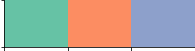

In [3]:
test_pal = sns.color_palette('Set2', 3)
sns.palplot(test_pal)

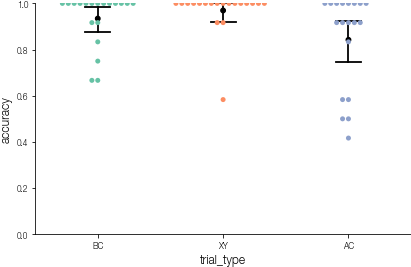

In [4]:
tests = df.loc[df['trial_type'] != 'AB'].groupby(['subject', 'trial_type'], as_index=False).mean()
sns.swarmplot(x='trial_type', y='accuracy', order=['BC', 'XY', 'AC'], 
              palette=test_pal, data=tests);
g = sns.pointplot(x='trial_type', y='accuracy', order=['BC', 'XY', 'AC'],
                   join=False, capsize=.2, color='k', data=tests)
g.set_ylim(0, 1);

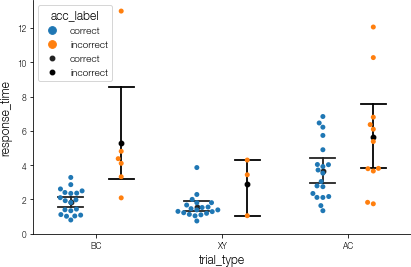

In [5]:
tests = df.loc[df['trial_type'] != 'AB'].groupby(['subject', 'trial_type', 'accuracy'], as_index=False).mean()
tests['acc_label'] = tests.accuracy.map({0: 'incorrect', 1: 'correct'})
g = sns.swarmplot(x='trial_type', y='response_time', hue='acc_label', 
                  hue_order=['correct', 'incorrect'], dodge=True,
                  order=['BC', 'XY', 'AC'], data=tests);
g = sns.pointplot(x='trial_type', y='response_time', hue='acc_label', 
                  hue_order=['correct', 'incorrect'], dodge=True,
                  join=False, capsize=.2,
                  color='k', order=['BC', 'XY', 'AC'], data=tests);

## BC and XY response times on correct trials

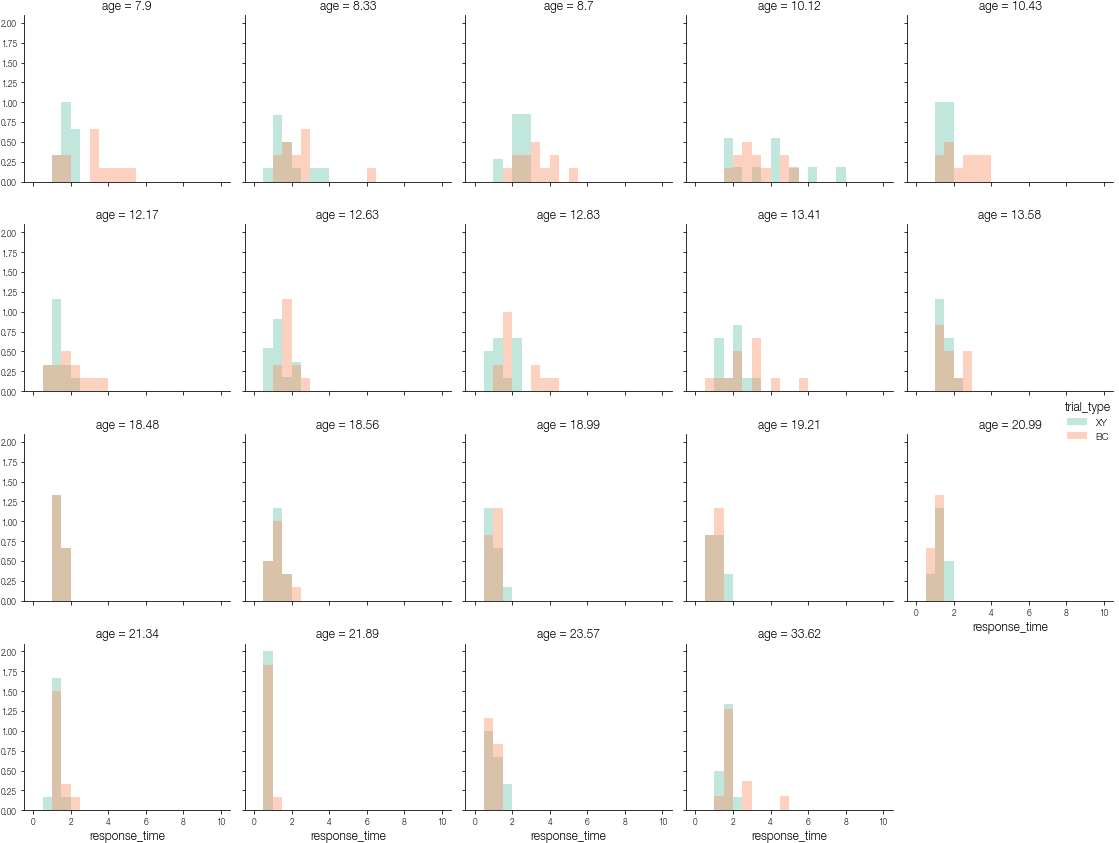

In [6]:
g = sns.FacetGrid(col='age', col_wrap=5, hue='trial_type', palette=test_pal,
                  data=df.query("trial_type == 'BC' or trial_type == 'XY' and accuracy == 1"))
g = (g.map(sns.distplot, 'response_time', norm_hist=True, kde=False,
           bins=np.linspace(0, 10, 21))
      .add_legend())

## BC and XY response times on incorrect trials

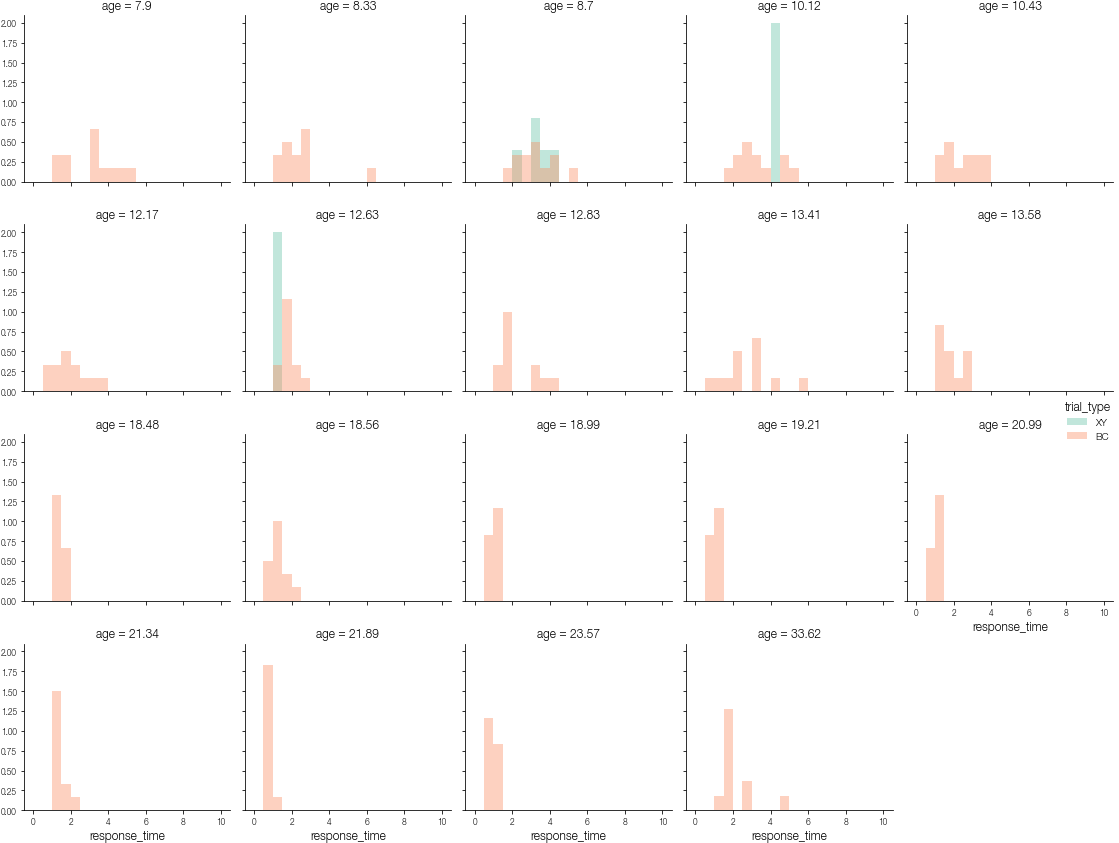

In [7]:
g = sns.FacetGrid(col='age', col_wrap=5, hue='trial_type', palette=test_pal,
                  data=df.query("trial_type == 'BC' or trial_type == 'XY' and accuracy == 0"))
g = (g.map(sns.distplot, 'response_time', norm_hist=True, kde=False,
           bins=np.linspace(0, 10, 21))
      .add_legend())

## AC response times

/Users/morton/anaconda3/envs/devreact/lib/python3.8/site-packages/numpy/lib/histograms.py:908: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges


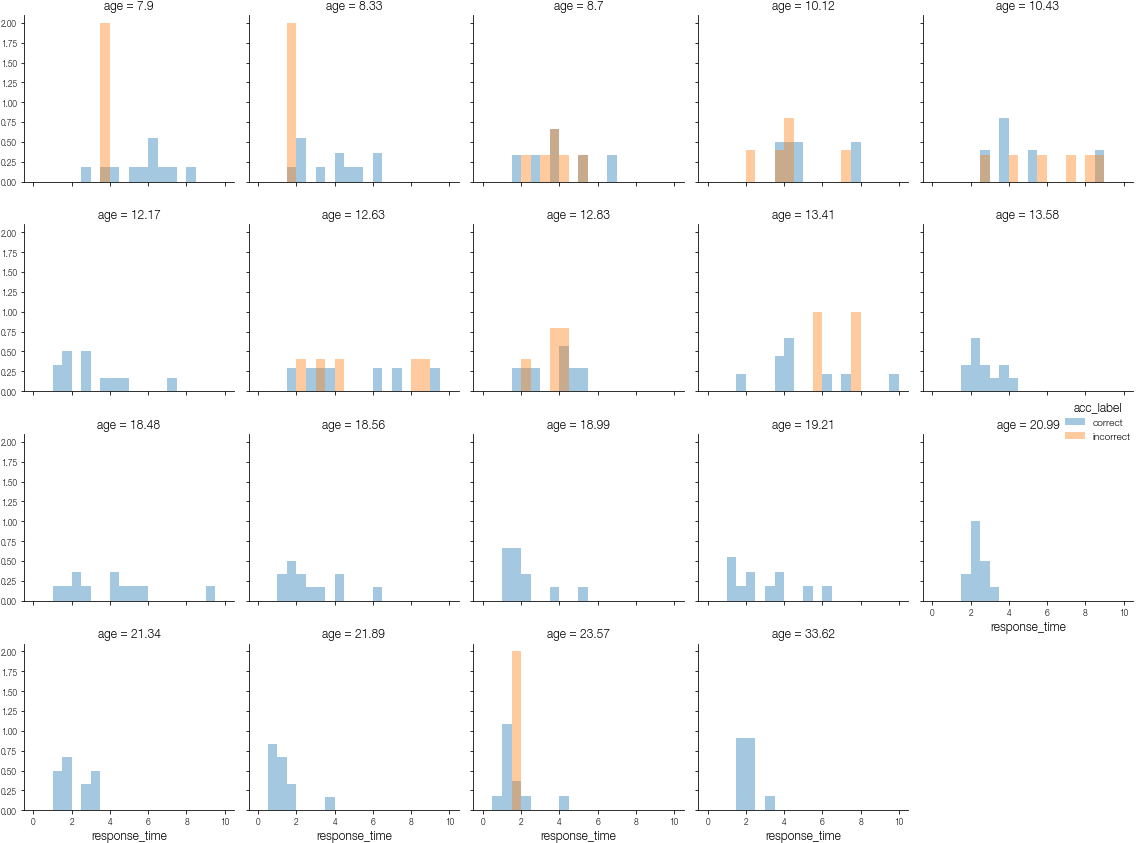

In [8]:
g = sns.FacetGrid(col='age', col_wrap=5, hue='acc_label', 
                  data=df.query("trial_type == 'AC'"))
g = (g.map(sns.distplot, 'response_time', norm_hist=True, kde=False,
           bins=np.linspace(0, 10, 21))
      .add_legend())